In [1]:
import os

print(os.listdir())

['.config', 'winequality.csv.csv', 'sample_data']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('winequality.csv.csv')

# Display first 5 rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Information about dataset
df.info()

# Statistical summary
df.describe()

# First 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Missing values
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


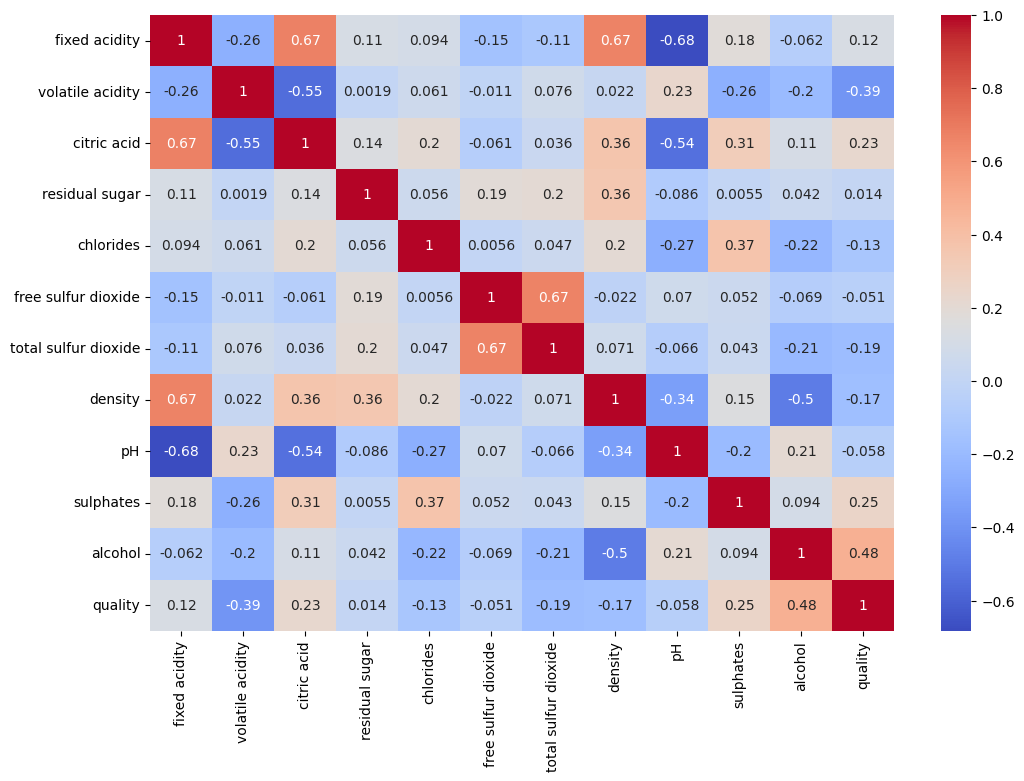

In [6]:
# Correlation matrix
correlation = df.corr()

# Correlation with quality
print(correlation['quality'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [7]:
# Create quality_label column
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Check first 5 rows
print(df[['quality', 'quality_label']].head())

   quality  quality_label
0        5              0
1        5              0
2        5              0
3        6              0
4        5              0


In [8]:
# Features (X)
X = df.drop(['quality', 'quality_label'], axis=1)

# Target (y)
y = df['quality_label']

print(X.head())
print(y.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
0    0
1

In [9]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1279, 11)
Testing shape: (320, 11)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.859375
Precision: 0.55
Recall: 0.23404255319148937
F1 Score: 0.3283582089552239

Confusion Matrix:
[[264   9]
 [ 36  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       273
           1       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320



In [11]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression on scaled data
lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled, y_train)

# Prediction
y_pred_scaled = lr_scaled.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall:", recall_score(y_test, y_pred_scaled))
print("F1 Score:", f1_score(y_test, y_pred_scaled))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.865625
Precision: 0.5909090909090909
Recall: 0.2765957446808511
F1 Score: 0.37681159420289856

Confusion Matrix:
[[264   9]
 [ 34  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       273
           1       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320



In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Create models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Store accuracy
results = {}

# Train and test each model
for name, model in models.items():

    # Train model
    model.fit(X_train_scaled, y_train)

    # Prediction
    pred = model.predict(X_test_scaled)

    # Accuracy
    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(name)
    print("Accuracy:", acc)
    print("-" * 30)

# Best model
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Logistic Regression
Accuracy: 0.865625
------------------------------
KNN
Accuracy: 0.88125
------------------------------
Decision Tree
Accuracy: 0.871875
------------------------------
Best Model: KNN


In [13]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Train GridSearch
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_knn = grid_search.best_estimator_

# Prediction
best_pred = best_knn.predict(X_test_scaled)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1 Score:", f1_score(y_test, best_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Accuracy: 0.921875
Precision: 0.7894736842105263
Recall: 0.6382978723404256
F1 Score: 0.7058823529411765

Confusion Matrix:
[[265   8]
 [ 17  30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       273
           1       0.79      0.64      0.71        47

    accuracy                           0.92       320
   macro avg       0.86      0.80      0.83       320
weighted avg       0.92      0.92      0.92       320



                 Feature  Importance
10               alcohol    0.201200
9              sulphates    0.126218
1       volatile acidity    0.110925
3         residual sugar    0.097624
6   total sulfur dioxide    0.092255
5    free sulfur dioxide    0.081969
4              chlorides    0.069198
7                density    0.064104
0          fixed acidity    0.064059
2            citric acid    0.053145
8                     pH    0.039303


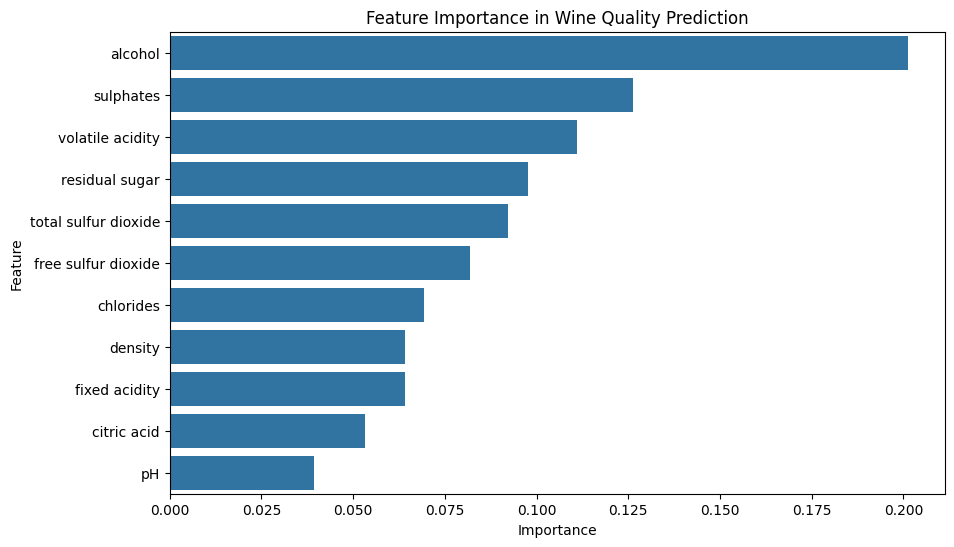

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Get feature importance
importance = dt_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
print(feature_importance)

# Plot graph
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance in Wine Quality Prediction")
plt.show()